In [20]:
import warnings
warnings.filterwarnings("ignore")
from pydantic import BaseModel, Field
from typing import List, TypedDict, Literal

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
load_dotenv()


True

In [21]:
docs = ( PyPDFLoader('./Company_Profile.pdf').load()
        + PyPDFLoader('./Company_Policies.pdf').load()
        + PyPDFLoader('./Product_and_Pricing.pdf').load())

In [22]:
#Chunking,Embeddings Generation,Store in FAISS,Retriever

chunks = RecursiveCharacterTextSplitter(chunk_size=600,chunk_overlap=150).split_documents(docs)
Embedding_model = OpenAIEmbeddings(model='text-embedding-3-large')
Vector_Store = FAISS.from_documents(chunks,Embedding_model)
retriever = Vector_Store.as_retriever(search_kwargs={'k':4})

In [23]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [24]:
# state graph

class State(TypedDict):
    question: str
    need_retrieval: bool
    retrieved_context: List[Document]
    relevant_context: List[Document]
    context: str #context is joined string of relevant_context
    answer: str
    # Post-generation check - Hellucination Check
    Is_supportive : Literal["Supportive","Partially Supportive","Non-Supportive"]
    evidence: List[str]

    #Usefulness check
    retrieval_query: str
    rewrite_tries: int
    isuse: Literal["useful", "not_useful"]
    use_reason: str

    retry_count: int

In [25]:
# 1.Decide Retrieval needed or not --Node

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


class Retrieval_decision(BaseModel):
    Need_retrieval:bool= Field(...,
    description="True if external documents are needed to answer the question, otherwise False")
    
llm_with_structured_output = llm.with_structured_output(Retrieval_decision)

def decide_retrieval(state:State) -> bool:

    retrieval_decision = llm_with_structured_output.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
        )
    return {"need_retrieval": retrieval_decision.Need_retrieval}

In [26]:
# 2.Generate Direct Answer Node (for questions that don't need retrieval)

direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct_answer(state:State):

    answer = llm.invoke(direct_generation_prompt.format_messages(question=state["question"])).content
    return {"answer": answer}

In [27]:
# 3.Retrieve Context for the questions which needs retrieval-Node
def retrieve(state:State):
    q=state.get("retrieval_query",) or state["question"]
    return {"retrieved_context": retriever.invoke(q)}

In [28]:
# 4.Check retrieved context is relevant to the question-Node

relevance_check_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Check if the following context is relevant to the question. Return JSON that matches this schema:\n"
         "{{'is_relevant': boolean}}\n\n"
         "Guidelines:\n"
         "- is_relevant=True if the context is relevant to the question, otherwise False\n"
         "- If unsure, choose True."),
        ("human", "Question: {question}\nContext: {context}"),
    ]
)

class Relevance_check(BaseModel):
    Is_relevant: bool = Field(...,
    description="True if the context is relevant to the question, otherwise False")
    
llm_relevance_check = llm.with_structured_output(Relevance_check)

def Is_relevant(state:State):
    relevant_context: List[Document] = [] 

    for doc in state["retrieved_context"]:
        decision = llm_relevance_check.invoke(
            relevance_check_prompt.format_messages(question=state["question"], context=doc.page_content)
        )
        if decision.Is_relevant:
            relevant_context.append(doc)

    return {"relevant_context": relevant_context}   

In [29]:
# 5.Generate answer from relevant context-Node
generate_from_context_prompt = ChatPromptTemplate.from_messages(
    [
    ("system", "Answer the question using ONLY the following context. If the context doesn't contain the answer, say so.\n\nContext:\n{context}"),
    ("human", "{question}"),
    ]
)
def generate_from_context(state:State):

    context =  "\n\n".join([doc.page_content for doc in state["relevant_context"]]).strip()
    answer = llm.invoke(generate_from_context_prompt.format_messages(context=context, question=state["question"])).content
    return {"answer": answer ,"context": context}


In [30]:
# 6.No relevant context found - Node
def no_relevant_context(state:State):
    return {"answer": "No relevant context found", "context": "", "Is_supportive": "Non-Supportive", "evidence": []}


In [31]:
# 7.Hellucination Check - Node
check_hellucination_prompt = ChatPromptTemplate.from_messages([
        ("system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)
class Hellucination_check(BaseModel):
    Is_supportive: Literal["Fully Supportive","Partially Supportive","Non-Supportive"]= Field(...,description="Supportive if the answer is directly supported by the context, Partially Supportive if the answer is partially supported by the context, Non-Supportive if the answer is not supported by the context")
    Evidence: List[str]= Field(...,description="List of evidence for the answer",default_factory=list)

llm_hellucination_check = llm.with_structured_output(Hellucination_check)

def Is_Supportive(state:State):
    decision = llm_hellucination_check.invoke(
        check_hellucination_prompt.format_messages(
            question=state["question"],
            answer=state["answer"],
            context=state["context"]
        )
    )
    return {"Is_supportive": decision.Is_supportive, "evidence": decision.Evidence}

In [32]:
#8.revise answer node
revise_answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)
def revise_answer(state:State):
    decision = llm.invoke(revise_answer_prompt.format_messages(
        question=state["question"],
        answer=state["answer"],
        context=state["context"]
    ))
    return {"answer": decision.content, 
        "retry_count": state.get("retry_count", 0) + 1 
    }
    

In [33]:
def accept_answer(state: State):
    return {}  # keep answer as-is

In [34]:
# 8.Is USEFULNESS check - Node
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(..., description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_llm = llm.with_structured_output(IsUSEDecision)

def is_use(state: State):
    decision: IsUSEDecision = isuse_llm.invoke(
        isuse_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
        )
    )
    return {"isuse": decision.isuse, "use_reason": decision.reason}

MAX_REWRITE_TRIES = 3  # tune (2–4 is usually fine)

def route_after_isuse(state: State) -> Literal["END", "rewrite_question", "no_answer_found"]:
    if state.get("isuse") == "useful":
        return "END"

    if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "no_answer_found"

    return "rewrite_question"

In [35]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)



rewrite_llm = llm.with_structured_output(RewriteDecision)

def rewrite_question(state: State):
    decision: RewriteDecision = rewrite_llm.invoke(
        rewrite_for_retrieval_prompt.format_messages(
            question=state["question"],
            retrieval_query=state.get("retrieval_query", ""),
            answer=state.get("answer", ""),
        )
    )

    return {
        "retrieval_query": decision.retrieval_query,
        "rewrite_tries": state.get("rewrite_tries", 0) + 1,
        # optional: reset these so next pass is clean
        "retrieved_context": [],
        "relevant_context": [],
        "context": "",
    }

In [36]:
# a.Router Node to check if retrieval is needed or not
def router_retrieval_check(state:State) -> Literal["retrieve","generate_direct_answer"]:
    if state["need_retrieval"]:
        return "retrieve"
    else:
        return "generate_direct_answer"   

In [37]:
# b.Router Node to check if relevant context is found or not

def router_relevance_check(state:State) -> Literal["generate_from_context","no_relevant_context"]:

    if state["relevant_context"]:
        return "generate_from_context"
    else:
        return "no_relevant_context"


In [38]:
# c. Router Node to check if the answer is hellucinated or not
max_retries = 10
def router_hellucination_check(state:State) -> Literal["acceptable_answer","revise_answer"]:
    is_sup = state.get("Is_supportive","")
    rc = state.get("retry_count",0)
    if is_sup == "Fully Supportive":
        out = "acceptable_answer"
    elif rc >= max_retries:
        out = "acceptable_answer"
    else:
        out = "revise_answer"
    return out


In [42]:
graph = StateGraph(State)

graph.add_node("decide_retrieval", decide_retrieval)
graph.add_node("generate_direct_answer", generate_direct_answer)
graph.add_node("retrieve", retrieve)
graph.add_node("Is_relevant", Is_relevant)
graph.add_node("generate_from_context", generate_from_context)
graph.add_node("no_relevant_context", no_relevant_context)
graph.add_node("Is_Supportive", Is_Supportive)
graph.add_node("Revise_Answer", revise_answer)
graph.add_node("Acceptable_Answer", accept_answer)
graph.add_node("IsUSE", is_use)
graph.add_node("rewrite_question", rewrite_question)

graph.add_edge(START, "decide_retrieval")
graph.add_conditional_edges(
    "decide_retrieval",
    router_retrieval_check,
    {
        "generate_direct_answer": "generate_direct_answer",
        "retrieve": "retrieve"
    }
)

graph.add_edge("generate_direct_answer", END)
graph.add_edge("retrieve", "Is_relevant")
graph.add_conditional_edges("Is_relevant", 
    router_relevance_check,
    {
        "generate_from_context":"generate_from_context",
        "no_relevant_context":"no_relevant_context"
    }
)

graph.add_edge("no_relevant_context", END)
# Always run hallucination check after generating from context
graph.add_edge("generate_from_context", "Is_Supportive")
graph.add_conditional_edges("Is_Supportive", 
    router_hellucination_check,
    {
        "acceptable_answer": "IsUSE",
        "revise_answer": "Revise_Answer"
    }
)

graph.add_edge("Revise_Answer", "Is_Supportive")
# --------------------
# IsUSE routing
#   - useful -> END
#   - not_useful -> rewrite_question -> retrieve (try again)
#   - give up -> no_answer_found -> END
# --------------------
graph.add_conditional_edges(
    "IsUSE",
    route_after_isuse,
    {
        "END": END,
        "rewrite_question": "rewrite_question",
        "no_answer_found": "no_relevant_context",
    },
)

# rewrite -> retrieve -> relevance -> ...
graph.add_edge("rewrite_question", "retrieve")


app = graph.compile()

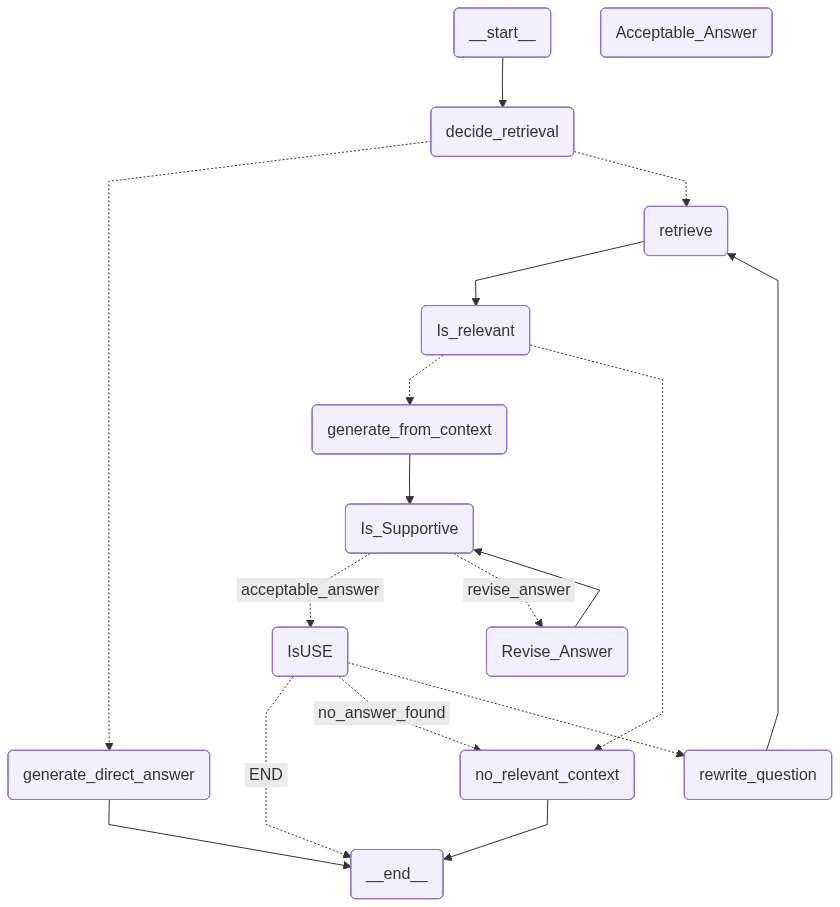

In [43]:
app

In [45]:
# -----------------------------
# Run the graph
# -----------------------------
initial_state = {
    "question": "Describe NexaAI’s company culture.",
    "need_retrieval": False,
    "retrieval_query": "What is the refund policy of NexaAI",  # important
    "rewrite_tries": 0,                                        # important
    "retrieved_context": [],
    "relevant_context": [],
    "context": "",
    "answer": "",
    "Is_supportive": "",
    "evidence": [],
    "retry_count": 0,
    "isuse": "not_useful",
    "use_reason": "",
}


result = app.invoke(
    initial_state,
    config={"recursion_limit": 80},  # allow revise → verify loops
)

# -----------------------------
# Debug / inspection output (clean + complete)
# -----------------------------
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state.get("question"))
print("Need Retrieval:", result.get("need_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retry_count", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("retrieved_context", []) or []))
print("  Relevant docs:", len(result.get("relevant_context", []) or []))

# Optional: show sources/pages for relevant docs
relevant_context = result.get("relevant_context", []) or []
if relevant_context:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_context, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  Is_supportive:", result.get("Is_supportive"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")





===== RAG EXECUTION RESULT =====

Question: Describe NexaAI’s company culture.
Need Retrieval: True
Rewrite tries (retrieval): 0
Support revise tries: 10

Retrieval:
  Total retrieved docs: 4
  Relevant docs: 1

Relevant docs (source/page):
  1. source=./Company_Policies.pdf, page=0, title=(anonymous)

Verification (IsSUP):
  Is_supportive: Partially Supportive
  evidence:
   - NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
   - Employees are encouraged to maintain a healthy work-life balance.

Usefulness (IsUSE):
  isuse: useful
  reason: The answer provides specific details about NexaAI's company culture.

Final Answer:
- "NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace."
- "Employees are encouraged to maintain a healthy work-life balance."


